# Exploring Document Loaders in LangChain

## Install Dependencies

In [ ]:
!pip install langchain==0.3.18
!pip install langchain-groq==0.2.4
!pip install langchain-community==0.3.17

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.6 MB/s eta 0:00:00


In [ ]:
# install OCR dependencies for unstructured
!sudo apt-get install tesseract-ocr
!sudo apt-get install poppler-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 20 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (4,740 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debc

In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 85.0 MB/s eta 0:00:00


## Document Loaders

Document loaders are used to import data from various sources into LangChain as `Document` objects. A `Document` typically includes a piece of text along with its associated metadata.

### Examples of Document Loaders:

- **Text File Loader:** Loads data from a simple `.txt` file.
- **Web Page Loader:** Retrieves the text content from any web page.

### Functionality:

- **Load Method:** Each document loader has a `load` method that enables the loading of data as documents from a pre-configured source.
- **Lazy Load Option:** Some loaders also support a "lazy load" feature, which allows data to be loaded into memory gradually as needed.

For more detailed information, visit [LangChain's document loader documentation](https://docs.langchain.com/oss/javascript/langchain/knowledge-base#1-documents-and-document-loaders).


### Text Loader

The simplest loader reads in a file as text and places it all into one document.



In [ ]:
!curl -o README.md https://raw.githubusercontent.com/langchain-ai/langchain/master/README.md

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  9932  100  9932    0     0  57015      0 --:--:-- --:--:-- --:--:-- 57080


In [ ]:
from langchain_community.document_loaders import TextLoader

loader = TextLoader("./README.md")
doc = loader.load()

In [ ]:
len(doc)

1

In [ ]:
type(doc[0])

langchain_core.documents.base.Document

In [ ]:
doc[0].metadata

{'source': './README.md'}

In [ ]:
print(doc[0].page_content[:3000])

# 🦜️🔗 LangChain

⚡ Build context-aware reasoning applications ⚡

[![Release Notes](https://img.shields.io/github/release/langchain-ai/langchain?style=flat-square)](https://github.com/langchain-ai/langchain/releases)
[![CI](https://github.com/langchain-ai/langchain/actions/workflows/check_diffs.yml/badge.svg)](https://github.com/langchain-ai/langchain/actions/workflows/check_diffs.yml)
[![PyPI - License](https://img.shields.io/pypi/l/langchain-core?style=flat-square)](https://opensource.org/licenses/MIT)
[![PyPI - Downloads](https://img.shields.io/pypi/dm/langchain-core?style=flat-square)](https://pypistats.org/packages/langchain-core)
[![GitHub star chart](https://img.shields.io/github/stars/langchain-ai/langchain?style=flat-square)](https://star-history.com/#langchain-ai/langchain)
[![Open Issues](https://img.shields.io/github/issues-raw/langchain-ai/langchain?style=flat-square)](https://github.com/langchain-ai/langchain/issues)
[![Open in Dev Containers](https://img.shields.io/static

### PDF Loaders

[Portable Document Format (PDF)](https://en.wikipedia.org/wiki/PDF), standardized as ISO 32000, is a file format developed by Adobe in 1992 to present documents, including text formatting and images, in a manner independent of application software, hardware, and operating systems.

LangChain integrates with a host of PDF parsers. Some are simple and relatively low-level; others will support OCR and image-processing, or perform advanced document layout analysis. The right choice will depend on your use-case and through experimentation.

Here we will see how to load PDF documents into the LangChain `Document` format

We download a research paper to experiment with

If the following command fails you can download the paper manually by going to http://arxiv.org/pdf/2103.15348.pdf, save it as `layoutparser_paper.pdf`and upload it on the left in Colab from the upload files option

In [ ]:
!wget -O 'layoutparser_paper.pdf' 'http://arxiv.org/pdf/2103.15348.pdf'

--2025-02-20 05:49:07--  http://arxiv.org/pdf/2103.15348.pdf
Resolving arxiv.org (arxiv.org)... 151.101.67.42, 151.101.131.42, 151.101.3.42, ...
Connecting to arxiv.org (arxiv.org)|151.101.67.42|:80... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: https://arxiv.org/pdf/2103.15348 [following]
--2025-02-20 05:49:07--  https://arxiv.org/pdf/2103.15348
Connecting to arxiv.org (arxiv.org)|151.101.67.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4686220 (4.5M) [application/pdf]
Saving to: ‘layoutparser_paper.pdf’

layoutparser_paper. 100%[===================>]   4.47M  --.-KB/s    in 0.06s   

2025-02-20 05:49:07 (80.6 MB/s) - ‘layoutparser_paper.pdf’ saved [4686220/4686220]



#### PyMuPDFLoader

This is the fastest of the PDF parsing options, and contains detailed metadata about the PDF and its pages, as well as returns one document per page. It uses the `pymupdf` library internally.

In [ ]:
from langchain_community.document_loaders import PyMuPDFLoader

loader = PyMuPDFLoader("./layoutparser_paper.pdf")
pages = loader.load()

In [ ]:
len(pages)

16

In [ ]:
pages[0]

Document(metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2021-06-22T01:27:10+00:00', 'source': './layoutparser_paper.pdf', 'file_path': './layoutparser_paper.pdf', 'total_pages': 16, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2021-06-22T01:27:10+00:00', 'trapped': '', 'modDate': 'D:20210622012710Z', 'creationDate': 'D:20210622012710Z', 'page': 0}, page_content='LayoutParser: A Uniﬁed Toolkit for Deep\nLearning Based Document Image Analysis\nZejiang Shen1 (\x00), Ruochen Zhang2, Melissa Dell3, Benjamin Charles Germain\nLee4, Jacob Carlson3, and Weining Li5\n1 Allen Institute for AI\nshannons@allenai.org\n2 Brown University\nruochen zhang@brown.edu\n3 Harvard University\n{melissadell,jacob carlson}@fas.harvard.edu\n4 University of Washington\nbcgl@cs.washington.edu\n5 University of Waterloo\nw422li@uwaterloo.ca\nAbstract. Recent advances in document image analysis (DIA) have been\nprimarily driven 

In [ ]:
pages[0].metadata

{'producer': 'pdfTeX-1.40.21',
 'creator': 'LaTeX with hyperref',
 'creationdate': '2021-06-22T01:27:10+00:00',
 'source': './layoutparser_paper.pdf',
 'file_path': './layoutparser_paper.pdf',
 'total_pages': 16,
 'format': 'PDF 1.5',
 'title': '',
 'author': '',
 'subject': '',
 'keywords': '',
 'moddate': '2021-06-22T01:27:10+00:00',
 'trapped': '',
 'modDate': 'D:20210622012710Z',
 'creationDate': 'D:20210622012710Z',
 'page': 0}

In [ ]:
print(pages[0].page_content)

LayoutParser: A Uniﬁed Toolkit for Deep
Learning Based Document Image Analysis
Zejiang Shen1 ( ), Ruochen Zhang2, Melissa Dell3, Benjamin Charles Germain
Lee4, Jacob Carlson3, and Weining Li5
1 Allen Institute for AI
shannons@allenai.org
2 Brown University
ruochen zhang@brown.edu
3 Harvard University
{melissadell,jacob carlson}@fas.harvard.edu
4 University of Washington
bcgl@cs.washington.edu
5 University of Waterloo
w422li@uwaterloo.ca
Abstract. Recent advances in document image analysis (DIA) have been
primarily driven by the application of neural networks. Ideally, research
outcomes could be easily deployed in production and extended for further
investigation. However, various factors like loosely organized codebases
and sophisticated model conﬁgurations complicate the easy reuse of im-
portant innovations by a wide audience. Though there have been on-going
eﬀorts to improve reusability and simplify deep learning (DL) model
development in disciplines like natural language processing

In [ ]:
print(pages[4].page_content)

LayoutParser: A Uniﬁed Toolkit for DL-Based DIA
5
Table 1: Current layout detection models in the LayoutParser model zoo
Dataset
Base Model1 Large Model
Notes
PubLayNet [38]
F / M
M
Layouts of modern scientiﬁc documents
PRImA [3]
M
-
Layouts of scanned modern magazines and scientiﬁc reports
Newspaper [17]
F
-
Layouts of scanned US newspapers from the 20th century
TableBank [18]
F
F
Table region on modern scientiﬁc and business document
HJDataset [31]
F / M
-
Layouts of history Japanese documents
1 For each dataset, we train several models of diﬀerent sizes for diﬀerent needs (the trade-oﬀbetween accuracy
vs. computational cost). For “base model” and “large model”, we refer to using the ResNet 50 or ResNet 101
backbones [13], respectively. One can train models of diﬀerent architectures, like Faster R-CNN [28] (F) and Mask
R-CNN [12] (M). For example, an F in the Large Model column indicates it has a Faster R-CNN model trained
using the ResNet 101 backbone. The platform is maintained and

# Bonus Content

#### UnstructuredPDFLoader

[Unstructured.io](https://unstructured-io.github.io/unstructured/) supports a common interface for working with unstructured or semi-structured file formats, such as Markdown or PDF. LangChain's [`UnstructuredPDFLoader`](https://api.python.langchain.com/en/latest/document_loaders/langchain_community.document_loaders.pdf.UnstructuredPDFLoader.html) integrates with Unstructured to parse PDF documents into LangChain [`Document`](https://api.python.langchain.com/en/latest/documents/langchain_core.documents.base.Document.html) objects.

In [ ]:
# takes 2 - 5 mins to install on Colab
!pip install "unstructured[all-docs]==0.16.10"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 27.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 14.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 46.0 MB/s eta 

After installing `unstructured`above remember to restart your session when it shows you the following popup, if it doesn't go to `Runtime`and `Restart Session`

![](https://i.imgur.com/UOBaotk.png)

Load PDF with complex parsing, table detection and chunking by sections

In [ ]:
from langchain_community.document_loaders import UnstructuredPDFLoader

# takes 3-4 mins on Colab
loader = UnstructuredPDFLoader('./layoutparser_paper.pdf',
                               strategy='hi_res',
                               extract_images_in_pdf=True,
                               infer_table_structure=True,
                               chunking_strategy="by_title",
                               max_characters=4500, # max size of chunks
                               new_after_n_chars=4500, # preferred size of chunks
                               mode='elements')
data = loader.load()

yolox_l0.05.onnx:   0%|          | 0.00/217M [00:00<?, ?B/s]

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [ ]:
len(data)

14

In [ ]:
[doc.metadata['category'] for doc in data]

['CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'Table',
 'CompositeElement',
 'CompositeElement',
 'Table',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement',
 'CompositeElement']

In [ ]:
data[0]

Document(metadata={'source': './layoutparser_paper.pdf', 'filetype': 'application/pdf', 'languages': ['eng'], 'last_modified': '2023-01-23T09:15:33', 'page_number': 1, 'orig_elements': 'eJzNWduO3DYS/RXuPCWLpkJKJCXNy9qxgY0TZzdInE0QxzB4KXXTVksNUZrxxMi/b5FSj3succYDtDFP3SyxWOSpUxdKL9+fQAtb6MbX3p2ckhNes1Jb4WjBhaaiyXNqHDOUOzCudoaXFT9ZkZMtjNrpUaPO+xPb94PznR4hpHGrL/ppfL0Bv96MKMlzxlBnEZ97N25Qyssk3fW+G6Pey5dCZmJFZJ1n5asVWYYqZ5mIQ85YVt8cz9NRcBIuwgjbeIof/Dtof9ppCyd/4oPGtzBe7CA9+uH7k7SXbj3pddrwyxPo1ievkjSMr7e9842HBEfO8oIyTvPiBatPuTwtiqi9Q83X3bQ1MMSDRBsjvBsTgPH53tjPnUVQ1v3g/wD3Is7AqdchhzIva1EzqpSwCLl0FIHOaelkbbkwQgk4GuSSZyxiqDIWMZ2HOGseVtUtw3nygwEcNT4d8wYqUUoDlDUNpwJkTrWzClmvilJzKbVxR6b5JY+Xoaiy/JDm18dp+sNB/ZMhV5XStWsUkhsZLpQTtNJMUVvkpqmsEabRx4Z8j+kyLBfW7yG+Pk7THwzk7JMh501TOJ03FEwlkeUCaJU3DXWiyqXQpiz5sZO5UjKTHyDnopBZfYDxDcGs8FHQHYxgR993ry3CGl7vht7gNJZJwQr1uQOBdGQi3xJOcvKK/I88IRkJxJKXOD4jFRGkIBKfZvjL0qzTQz9+A9rhorelKM5KKFVDRVljvNiC07pyhjY1UyXHIRTHdh4XeZ3xQ+9JlVVXvHdDkDQeTMycHWL9wo8t3Aa1sFqVNc+pVA1C3V

In [ ]:
print(data[0].page_content)

1

2021

2

0

2 n u J 1 2 ] V C . s c [ 2 v 8 4 3 5 1 . 3 0 1 2 :

v

arXiv

i

X

r

a

LayoutParser: A Uniﬁed Toolkit for Deep Learning Based Document Image Analysis

Zejiang Shen! (4), Ruochen Zhang”, Melissa Dell?, Benjamin Charles Germain Lee*, Jacob Carlson’, and Weining Li®

1 Allen Institute for AI shannons@allenai.org 2 Brown University ruochen zhang@brown.edu 3 Harvard University {melissadell,jacob carlson}@fas.harvard.edu 4 University of Washington bcgl@cs.washington.edu 5 University of Waterloo w422li@uwaterloo.ca

Abstract. Recent advances in document image analysis (DIA) have been primarily driven by the application of neural networks. Ideally, research outcomes could be easily deployed in production and extended for further investigation. However, various factors like loosely organized codebases and sophisticated model conﬁgurations complicate the easy reuse of im- portant innovations by a wide audience. Though there have been on-going eﬀorts to improve reusability and 

In [ ]:
data[3]

Document(metadata={'source': './layoutparser_paper.pdf', 'last_modified': '2023-01-23T09:15:33', 'text_as_html': "<table><tr><td>Dataset</td><td>| Base Model'|</td><td>| Notes</td></tr><tr><td>PubLayNet B8]|</td><td>F/M</td><td>Layouts of modern scientific documents</td></tr><tr><td>PRImA</td><td>M</td><td>Layouts of scanned modern magazines and scientific report</td></tr><tr><td>Newspaper</td><td>F</td><td>Layouts of scanned US newspapers from the 20th century</td></tr><tr><td>TableBank</td><td>F</td><td>Table region on modern scientific and business document</td></tr><tr><td>HJDataset</td><td>F/M</td><td>Layouts of history Japanese documents</td></tr></table>", 'filetype': 'application/pdf', 'languages': ['eng'], 'page_number': 5, 'orig_elements': 'eJyVVGFP2zAQ/StWvuwLbZOYkhQhpKEJbYgiNNinroqc5JpYJHZkO4MC++87O01p14A2NVLji+/dvXvPXrx4UEENwiQ8906JF7MUaByejGgM2ej4OILRLMzi0TSikAbR9ITOwDsiXg2G5cwwzHnxMilVzgUzoN26YmvZmqQEXpQGI2Ho+5izCT/y3JQYDSIXbSQXxuYtFjSajadHhMZ07C+PSL+eRv74xK4DGgbj44FAl4E

In [ ]:
data[3].page_content

'Dataset Base Model1 Large Model Notes PubLayNet [38] F / M M Layouts of modern scientiﬁc documents PRImA [3] M - Layouts of scanned modern magazines and scientiﬁc reports Newspaper [17] F - Layouts of scanned US newspapers from the 20th century TableBank [18] F F Table region on modern scientiﬁc and business document HJDataset [31] F / M - Layouts of history Japanese documents'

In [ ]:
from IPython.display import HTML

HTML(data[3].metadata['text_as_html'])

Dataset,| Base Model'|,| Notes
PubLayNet B8]|,F/M,Layouts of modern scientific documents
PRImA,M,Layouts of scanned modern magazines and scientific report
Newspaper,F,Layouts of scanned US newspapers from the 20th century
TableBank,F,Table region on modern scientific and business document
HJDataset,F/M,Layouts of history Japanese documents


In [ ]:
!pip install htmltabletomd

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for htmltabletomd: filename=htmltabletomd-1.0.0-py2.py3-none-any.whl size=3577 sha256=7f4980bac454d0286bb97155c0f8d51b4078de6a90fa8816b23a0fdb35c85abb
  Stored in directory: /root/.cache/pip/wheels/8e/ef/53/7288ca33eab4211fc5bc4febafe7e5552ba5bbaf8dd1839669
  Created wheel for html2markdown: filename=html2markdown-0.1.7-py3-none-any.whl size=5234 sha256=8eae4f53bc0fa3abaf6e17757c60d08d3e3c04737ed3b455a3b58dc38ccc9e69
  Stored in directory: /root/.cache/pip/wheels/fa/63/7b/e898c8d7cbb84d2538052c56fd849bfb43a472c1824acd2ef7
Successfully built htmltabletomd html2markdown


In [ ]:
data[3].metadata['text_as_html']

"<table><tr><td>Dataset</td><td>| Base Model'|</td><td>| Notes</td></tr><tr><td>PubLayNet B8]|</td><td>F/M</td><td>Layouts of modern scientific documents</td></tr><tr><td>PRImA</td><td>M</td><td>Layouts of scanned modern magazines and scientific report</td></tr><tr><td>Newspaper</td><td>F</td><td>Layouts of scanned US newspapers from the 20th century</td></tr><tr><td>TableBank</td><td>F</td><td>Table region on modern scientific and business document</td></tr><tr><td>HJDataset</td><td>F/M</td><td>Layouts of history Japanese documents</td></tr></table>"

In [ ]:
import htmltabletomd

print(htmltabletomd.convert_table(data[4].metadata['text_as_html']))

| | | |
| :--- | :--- | :--- |
| Dataset | &#124; Base Model'&#124; | &#124; Notes |
| PubLayNet B8]&#124; | F/M | Layouts of modern scientific documents |
| PRImA | M | Layouts of scanned modern magazines and scientific report |
| Newspaper | F | Layouts of scanned US newspapers from the 20th century |
| TableBank | F | Table region on modern scientific and business document |
| HJDataset | F/M | Layouts of history Japanese documents |



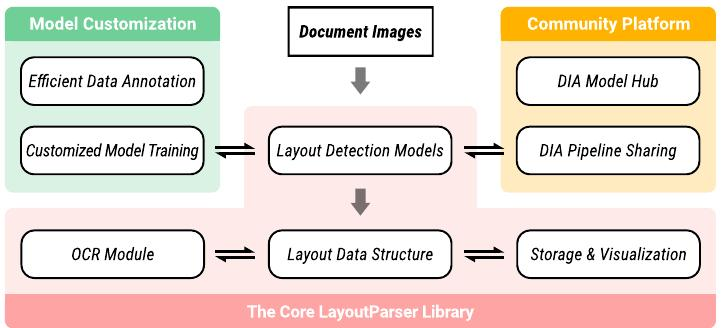

In [ ]:
from PIL import Image

Image.open('./figures/figure-4-1.jpg')

### Microsoft Office Document Loaders

The Microsoft Office suite of productivity software includes Microsoft Word, Microsoft Excel, Microsoft PowerPoint, Microsoft Outlook, and Microsoft OneNote. It is available for Microsoft Windows and macOS operating systems. It is also available on Android and iOS.

[Unstructured.io](https://docs.unstructured.io/open-source/introduction/overview) provides a variety of document loaders to load MS Office documents. Check them out [here](https://docs.unstructured.io/open-source/core-functionality/partitioning).

Here we will leverage LangChain's [`UnstructuredWordDocumentLoader`](https://api.python.langchain.com/en/latest/document_loaders/langchain_community.document_loaders.word_document.UnstructuredWordDocumentLoader.html) to load data from a MS Word document.

In [ ]:
!gdown 1DEz13a7k4yX9yFrWaz3QJqHdfecFYRV-

Downloading...
From: https://drive.google.com/uc?id=1DEz13a7k4yX9yFrWaz3QJqHdfecFYRV-
To: /content/Quantum Computing.docx
100% 11.4k/11.4k [00:00<00:00, 41.4MB/s]


Load word doc with complex parsing and section based chunks

In [ ]:
from langchain_community.document_loaders import UnstructuredWordDocumentLoader

loader = UnstructuredWordDocumentLoader('./Quantum Computing.docx',
                                        strategy='fast',
                                        chunking_strategy="by_title",
                                        max_characters=1000, # max limit of a document chunk
                                        mode='elements')
data = loader.load()

In [ ]:
len(data)

5

In [ ]:
print(data[0].page_content)

The Rise of Quantum Computing: A New Era of Innovation

For decades, classical computing has driven technological advancements, but the limitations of traditional binary processing are becoming evident as the world demands more computational power. Enter quantum computing—a revolutionary approach that leverages the principles of quantum mechanics to solve complex problems at unprecedented speeds.


In [ ]:
print(data[1].page_content)

Understanding Quantum Computing

Unlike classical computers that process information using bits (0s and 1s), quantum computers use qubits, which can exist in multiple states simultaneously due to superposition. This unique property allows quantum systems to process vast amounts of data in parallel, making them exponentially more powerful for specific tasks.

Another key principle, entanglement, enables qubits to be interconnected, meaning the state of one qubit is dependent on another, regardless of distance. This drastically enhances processing efficiency and speed, paving the way for breakthroughs in cryptography, materials science, and artificial intelligence.


In [ ]:
print(data[2].page_content)

Applications Transforming Industries

Drug Discovery & Healthcare
Quantum simulations can analyze molecular structures and interactions at an atomic level, accelerating drug discovery and personalized medicine. Companies like IBM and Google are already exploring quantum approaches to fight diseases like cancer and Alzheimer’s.

Financial Modeling
Financial markets involve complex, unpredictable variables. Quantum algorithms can optimize portfolios, manage risk, and predict market fluctuations with greater accuracy than classical computing methods.

Cybersecurity & Cryptography
Traditional encryption methods rely on mathematical complexity, which quantum computers could break in seconds. This has sparked the rise of post-quantum cryptography, aimed at developing secure algorithms resistant to quantum attacks.
